# Customer Churn Prediction & Model Deployment Pipeline
**Author:** pchaher03  
**Repository:** [[GitHub Link](https://github.com/pchaher03/customer-churn-prediction-model.git)] | **Live App:** [Streamlit App Link]

---

## Index
1. [Introduction](#1-introduction)
    * [1.1 Project overview](#11-project-overview)
    * [1.2 Business objective](#12-business-objective)
    * [1.3 Pipeline architecture](#13-pipeline-architecture)
2. [Understanding the dataset](#2-understanding-the-dataset)
    * [2.1 Importation of libraries and dataset](#21-importation-of-libraries-and-dataset)
    * [2.2 Column glossary](#22-column-glossary)
    * [2.3 Visuals before cleaning](#23-visuals-before-cleaning)
3. [Data cleaning](#3-data-cleaning)
    * [3.1 Things to do](#31-things-to-do)
    * [3.2 Visuals after cleaning](#32-visuals-after-cleaning)
        * [3.2.1 Continuous scatterplot matrix](#321-continuous-scatterplot-matrix)
        * [3.2.2 Full feature correlation matrix](#322-full-feature-correlation-matrix)
4. [Model training (Logistic Regression, RandomForest)](#4-model-training-logistic-regression-randomforest)
    * [4.1 Artifact](#41-artifact)
5. [Results](#5-results)
    * [5.1 Comparing performance](#51-comparing-performance)
    * [5.2 Confusion matrices](#52-confusion-matrices)
    * [5.3 Feature impact on churn](#53-feature-impact-on-churn)

---

# 1 Introduction

## 1.1 Project overview
Customer churn —the rate at which subscribers discontinue their service— is one of the most critical business metrics in the telecommunications industry. Because acquiring new customers is significantly more expensive than retaining existing ones, proactive churn mitigation directly protects recurring revenue.

This project delivers an end-to-end Machine Learning solution that processes customer demographic and usage data, executes feature engineering and categorical encoding, trains predictive classifiers, and exports a serialized model artifact ready for deployment in an interactive Streamlit application.

## 1.2 Business objective
* **Predict high-risk customers:** uncover key behavioral and contract patterns that precede customer attrition to enable targeted retention offers.
* **Model benchmark:** evaluate a baseline linear model (Logistic Regression) against a tree-based ensemble (Random Forest Classifier) to optimize for recall, precision, and overall classification performance.
* **Operationalization:** package the data preprocessing transformations and trained estimator into a single, serialized `.joblib` pipeline for real-time inference in a user-facing dashboard.

## 1.3 Pipeline architecture
1. **Data ingestion:** automated fetching of the Telco Customer Churn dataset via `kagglehub`.
2. **Exploratory data analysis (EDA):** auditing raw feature types, handling whitespace-imputed missing values, and assessing target variable class distribution.
3. **Data cleaning & feature engineering:** numeric parsing (converting `TotalCharges`), binary mapping, multi-class categorical simplification, and One-Hot Encoding (`pd.get_dummies`).
4. **Model training & evaluation:** stratified train/test splitting, feature scaling (`StandardScaler` within the Logistic Regression pipeline), class-weighted model fitting, and evaluation across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
5. **Artifact serialization:** exporting feature transformations and trained weights into a unified pipeline artifact to power `app.py`.

# 2 Understanding the dataset

## 2.1 Importation of libraries and dataset

Link to the dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

<div class="alert alert-block alert-info">
<b>💡 Note:</b> make sure to have every library needed <i>(check requirements.txt)</i> in your environment to run properly the notebook. 
</div>

In [125]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [126]:
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path
)

## 2.2 Column glossary

| Column Name | Description | Data Type / Values |
| :--- | :--- | :--- |
| **`customerID`** | Unique identifier for each customer | `String` (ID string) |
| **`gender`** | Gender of the customer | `Female`, `Male` |
| **`SeniorCitizen`** | Whether the customer is a senior citizen (1) or not (0) | `Integer` (`0`, `1`) |
| **`Partner`** | Whether the customer has a partner | `Yes`, `No` |
| **`Dependents`** | Whether the customer has dependents | `Yes`, `No` |
| **`tenure`** | Number of months the customer has stayed with the company | `Integer` (Months: `0` – `72`) |
| **`PhoneService`** | Whether the customer has a phone service | `Yes`, `No` |
| **`MultipleLines`** | Whether the customer has multiple phone lines | `Yes`, `No`, `No phone service` |
| **`InternetService`** | Customer’s internet service provider type | `DSL`, `Fiber optic`, `No` |
| **`OnlineSecurity`** | Whether the customer has online security add-on | `Yes`, `No`, `No internet service` |
| **`OnlineBackup`** | Whether the customer has online backup service | `Yes`, `No`, `No internet service` |
| **`DeviceProtection`** | Whether the customer has device protection plan | `Yes`, `No`, `No internet service` |
| **`TechSupport`** | Whether the customer has tech support plan | `Yes`, `No`, `No internet service` |
| **`StreamingTV`** | Whether the customer uses internet to stream TV | `Yes`, `No`, `No internet service` |
| **`StreamingMovies`** | Whether the customer uses internet to stream movies | `Yes`, `No`, `No internet service` |
| **`Contract`** | The contract term length of the customer | `Month-to-month`, `One year`, `Two year` |
| **`PaperlessBilling`** | Whether the customer has chosen paperless billing | `Yes`, `No` |
| **`PaymentMethod`** | The customer’s payment method | `Electronic check`, `Mailed check`, `Bank transfer (automatic)`, `Credit card (automatic)` |
| **`MonthlyCharges`** | The amount charged to the customer monthly | `Float` (Currency) |
| **`TotalCharges`** | The total amount charged to the customer | `Float` (Currency, stored as `String`) |
| **`Churn`** | Target Variable: Whether the customer churned | `Yes`, `No` |

In [127]:
# Let's take a quick glance at example rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [128]:
# Basic statistical review

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [129]:
# Basic lookup 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [130]:
# We can check every unique value in each column, to see if anything has a suspicious value.

for column in df:
    print(f"{column}: {df[column].unique()}")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)

<div class="alert alert-info">
    <b>💡 Note:</b> at this moment, there are some obvious cleanups needed: column id is not necessary, we need to format strings to binaries, 'TotalCharges' column to float, and we need to see what are we going to handle multiple flag data.
</div>

In [131]:
# Check out for nulls

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [132]:
# Churn distribution

df['Churn'].value_counts(normalize=False)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 2.3 Visuals before cleaning

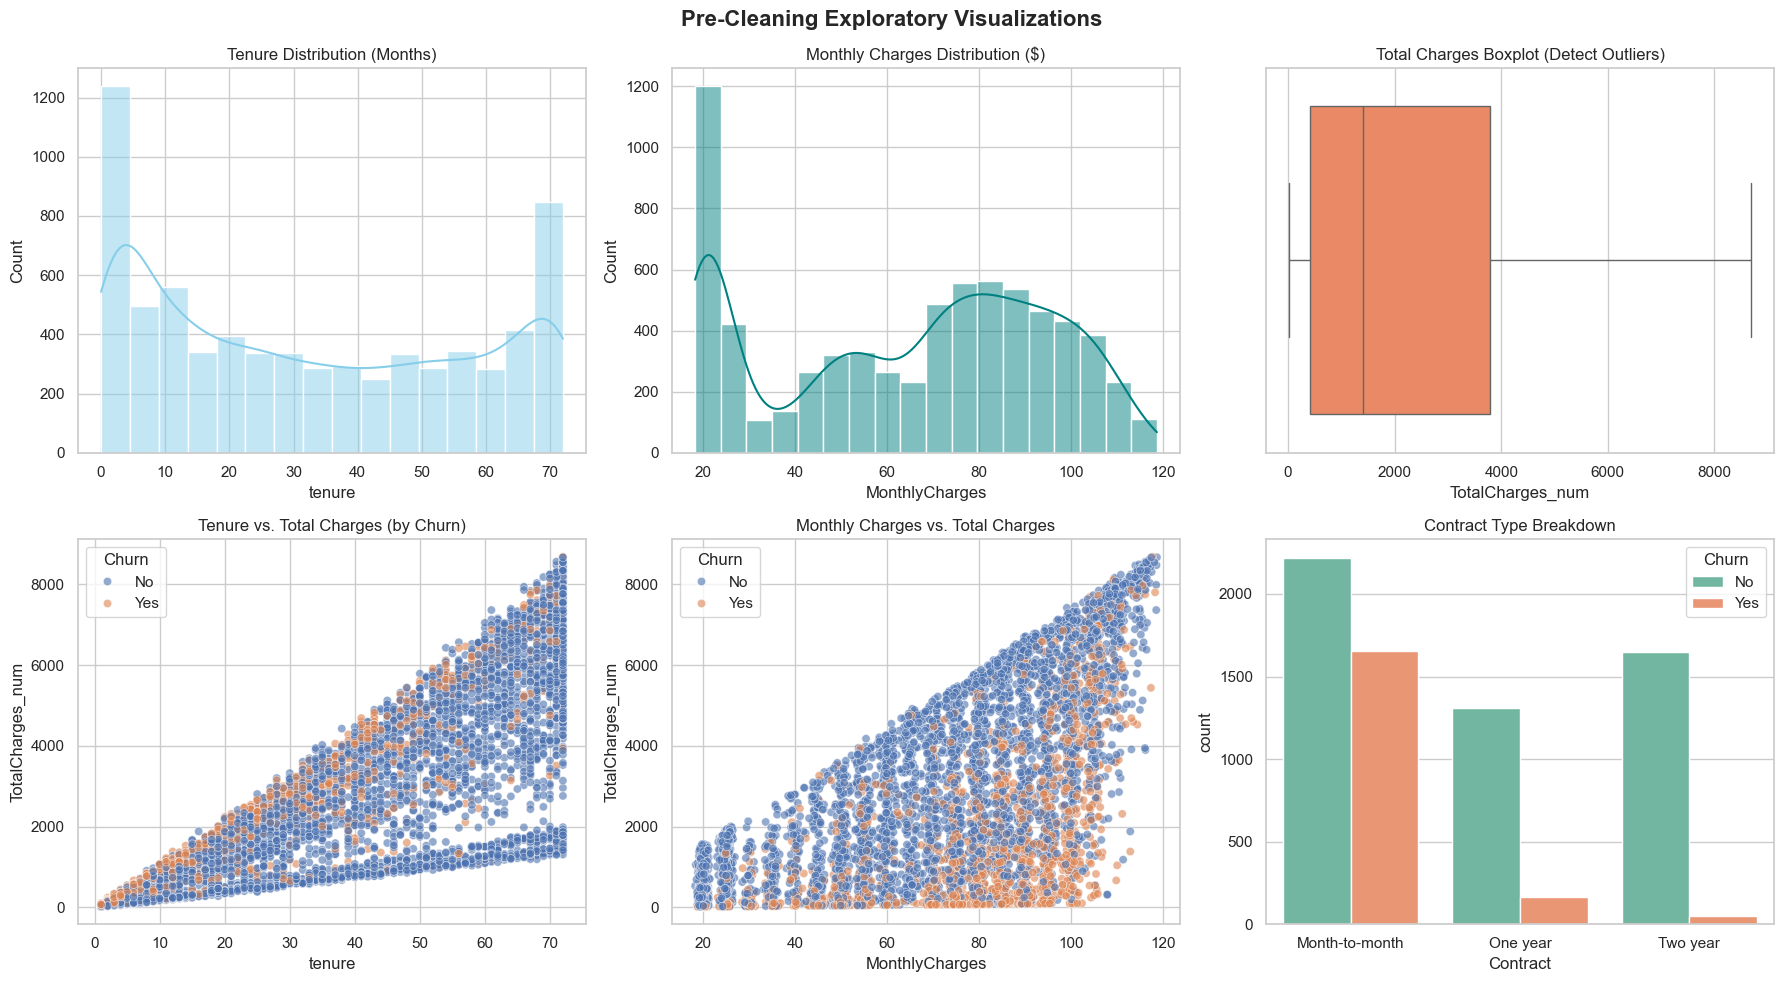

In [133]:
plot_df = df.copy()
plot_df['TotalCharges_num'] = pd.to_numeric(plot_df['TotalCharges'], errors='coerce')

# Set figure aesthetics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Pre-Cleaning Exploratory Visualizations', fontsize=16, fontweight='bold')

# --- DISTRIBUTIONS & OUTLIERS ---

# Tenure Distribution
sns.histplot(data=plot_df, x='tenure', kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Tenure Distribution (Months)')

# Monthly Charges Distribution
sns.histplot(data=plot_df, x='MonthlyCharges', kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Monthly Charges Distribution ($)')

# Total Charges Outliers (Box Plot)
sns.boxplot(data=plot_df, x='TotalCharges_num', ax=axes[0, 2], color='coral')
axes[0, 2].set_title('Total Charges Boxplot (Detect Outliers)')

# --- SCATTERPLOTS & CATEGORICAL DISTRIBUTIONS ---

# Tenure vs. Total Charges Scatter Plot
sns.scatterplot(
    data=plot_df, 
    x='tenure', 
    y='TotalCharges_num', 
    hue='Churn', 
    alpha=0.6, 
    ax=axes[1, 0]
)
axes[1, 0].set_title('Tenure vs. Total Charges (by Churn)')

# Monthly Charges vs. Total Charges Scatter Plot
sns.scatterplot(
    data=plot_df, 
    x='MonthlyCharges', 
    y='TotalCharges_num', 
    hue='Churn', 
    alpha=0.6, 
    ax=axes[1, 1]
)
axes[1, 1].set_title('Monthly Charges vs. Total Charges')

# Contract Class Distribution
sns.countplot(data=plot_df, x='Contract', hue='Churn', ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Contract Type Breakdown')

plt.tight_layout()
plt.show()

# 3 Data cleaning

## 3.1 Things to do

| Target Column(s) | Action Required | Output Type |
| :--- | :--- | :--- |
| `customer id` | Drop column | None |
| `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn`, `gender` | Map values | Binary (`0` / `1`) |
| `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Simplify flags | Binary (`0` / `1`) |
| `TotalCharges` | Cast data type | Float |
| `Contract`, `PaymentMethod` | One-Hot Encode | Binary Dummies |

In [134]:
# Dataset before cleaning

print(f"Dataset shape: {df.shape}")
print("\nData types count:")
print(df.dtypes.value_counts())
df.head()
df.describe()

Dataset shape: (7043, 21)

Data types count:
object     18
int64       2
float64     1
Name: count, dtype: int64


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [135]:
# Drop customerID if it exists (not useful for prediction)

if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges: convert empty strings (" ") to NaN, cast to float, fill missing with 0

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True))
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Simplify redundant multi-category flags ('No service' -> 'No')

no_service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in no_service_cols:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

# Convert simple 'Yes'/'No' and 'Female'/'Male' binary columns to 1 and 0

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

# Map gender (Female = 1, Male = 0)

if 'gender' in df.columns:
    df['gender'] = (df['gender'] == 'Female').astype(int)

# One-Hot Encode remaining multi-category features directly into df

cat_cols = ['InternetService', 'Contract', 'PaymentMethod'] + no_service_cols
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [136]:
# Verify results after cleaning

print(f"Dataset shape: {df.shape}")
print("\nData types count:")
print(df.dtypes.value_counts())
df.head()
df.describe()

Dataset shape: (7043, 24)

Data types count:
int64      22
float64     2
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_Yes,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.495244,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,0.265370,...,0.216101,0.335794,0.228880,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,0.441561,...,0.411613,0.472301,0.420141,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,...,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 3.2 Visuals after cleaning

### 3.2.1 Continuous scatterplot matrix

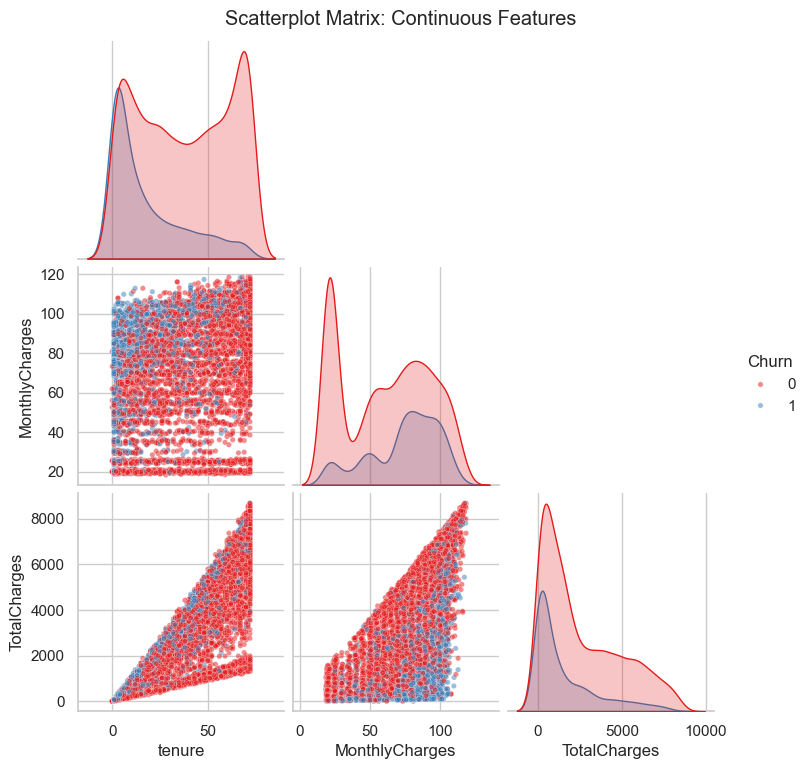

In [ ]:
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

# corner=True cuts redundant duplicate plots in half
sns.pairplot(
    df[continuous_cols], 
    hue='Churn', 
    corner=True, 
    palette='Set1',
    plot_kws={'alpha': 0.5, 's': 15}
)
plt.suptitle('Scatterplot Matrix: Continuous Features', y=1.02)
plt.show()

### 3.2.2 Full feature correlation matrix

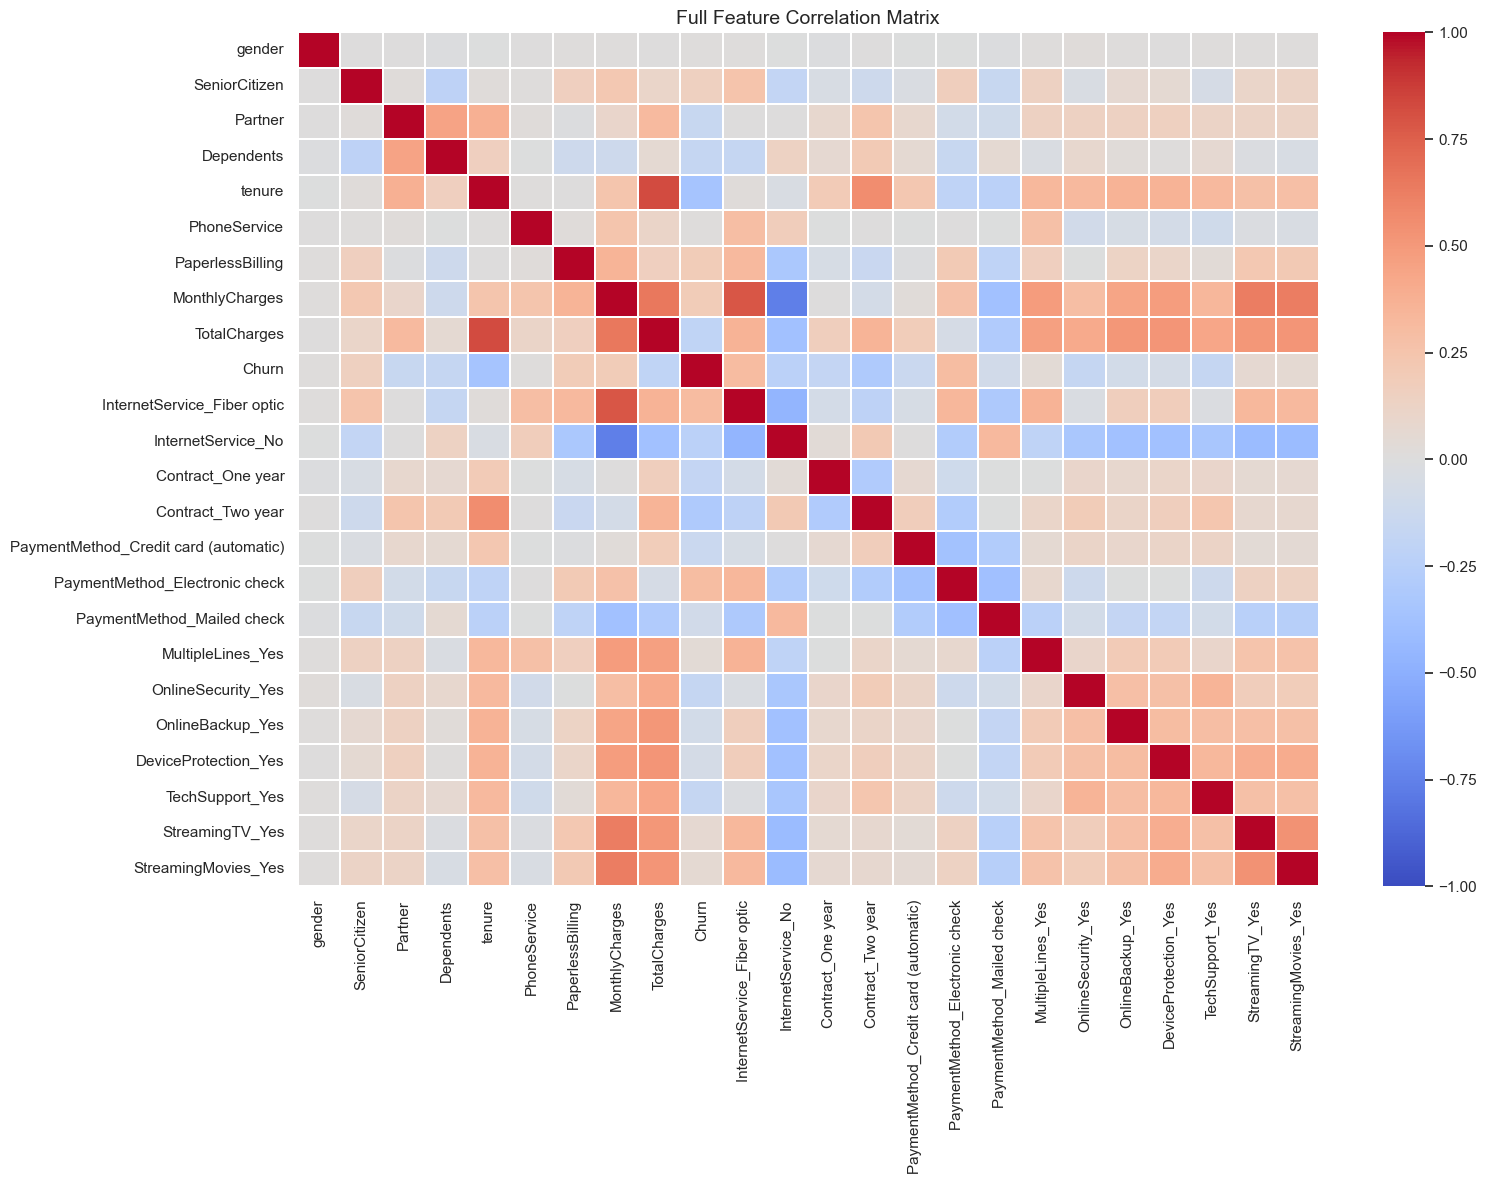

In [138]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    df.corr(), 
    cmap='coolwarm', 
    vmax=1.0, 
    vmin=-1.0, 
    linewidths=0.1, 
    annot=False # Set to True if you want numeric correlation values printed
)
plt.title('Full Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# 4 Model training (Logistic Regression, RandomForest)

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Scaled Logistic Regression (Pipeline prevents overwriting)
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

## 4.1 Artifact

In [140]:
# Bundle models and metadata into a dictionary
artifacts = {
    "logistic_regression": lr_model,  # Includes the StandardScaler pipeline automatically
    "random_forest": rf_model,
    "feature_columns": X_train.columns.tolist()
}

joblib.dump(artifacts, "churn_models.joblib")

['churn_models.joblib']

# 5 Results

## 5.1 Comparing performance

In [141]:
print("--- Logistic Regression ---")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(classification_report(y_test, lr_preds))

print("\n--- Random Forest ---")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")
print(classification_report(y_test, rf_preds))

--- Logistic Regression ---
ROC-AUC: 0.8415
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- Random Forest ---
ROC-AUC: 0.8280
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



## 5.2 Confusion matrices

We can see both models predict better retention than churn. 
This is explained by the dataset distribution --aproximately 70% of rows are retained, or churn = 0.

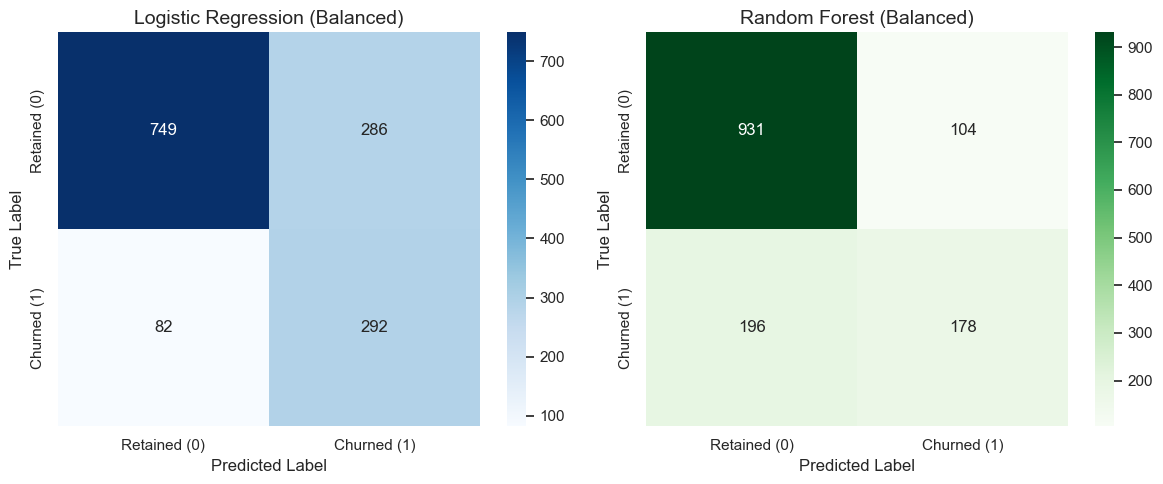

In [142]:
# Compute confusion matrices
cm_lr = confusion_matrix(y_test, lr_preds)
cm_rf = confusion_matrix(y_test, rf_preds)

# Set up side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Logistic Regression Confusion Matrix
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Retained (0)', 'Churned (1)'],
    yticklabels=['Retained (0)', 'Churned (1)']
)
axes[0].set_title('Logistic Regression (Balanced)', fontsize=14)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Plot Random Forest Confusion Matrix
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1],
    xticklabels=['Retained (0)', 'Churned (1)'],
    yticklabels=['Retained (0)', 'Churned (1)']
)
axes[1].set_title('Random Forest (Balanced)', fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

## 5.3 Feature impact on churn

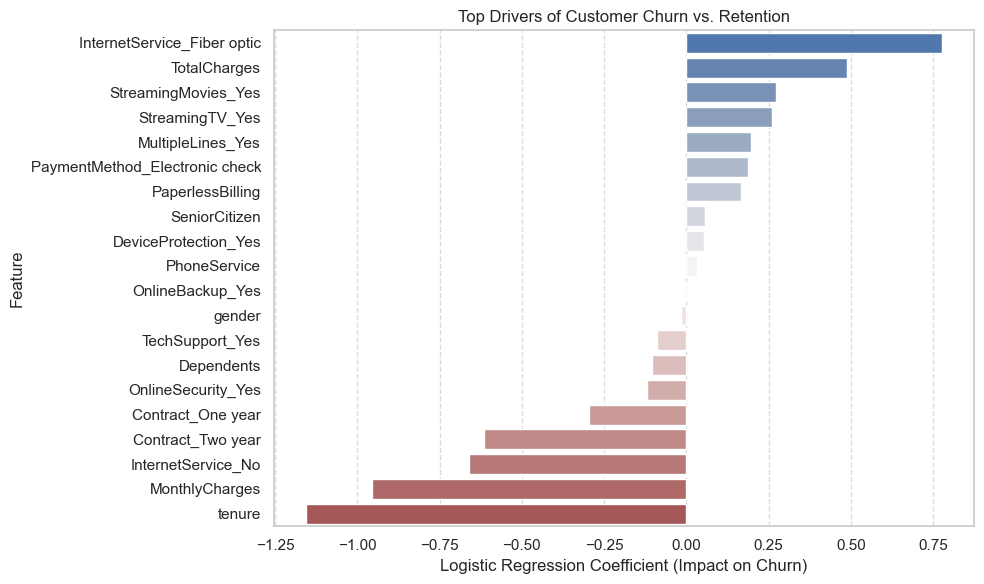

In [150]:
# Extract coefficients from the logistic regression pipeline step
model_step = lr_model.named_steps['logisticregression']
feature_names = X.columns

# Build a dataframe of feature weights
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_step.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Combine top 10 churn and retention drivers
plot_data = pd.concat([coef_df.head(10), coef_df.tail(10)])

# Plot top drivers
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x='Coefficient',
    y='Feature',
    hue='Feature',      # Fixed: Explicitly mapped hue to the y-axis variable
    palette='vlag',
    legend=False
)
plt.title('Top Drivers of Customer Churn vs. Retention')
plt.xlabel('Logistic Regression Coefficient (Impact on Churn)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()